# Week #6 Wavelet transform

In [1]:
!wget 'https://drive.google.com/uc?id=1Yox-XWM-PY9vFtDdzB_y_U3SK2paewwe' -O kitty.jpg

--2025-09-21 22:10:44--  https://drive.google.com/uc?id=1Yox-XWM-PY9vFtDdzB_y_U3SK2paewwe
Resolving drive.google.com (drive.google.com)... 2404:6800:4001:814::200e, 172.217.25.78
Connecting to drive.google.com (drive.google.com)|2404:6800:4001:814::200e|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1Yox-XWM-PY9vFtDdzB_y_U3SK2paewwe [following]
--2025-09-21 22:10:45--  https://drive.usercontent.google.com/download?id=1Yox-XWM-PY9vFtDdzB_y_U3SK2paewwe
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 2404:6800:4001:812::2001, 172.217.25.129
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|2404:6800:4001:812::2001|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 79570 (78K) [image/jpeg]
Saving to: ‘kitty.jpg’

kitty.jpg           100%[===================>]  77.71K  --.-KB/s    in 0.1s    

2025-09-21 22:10:48 (643 KB/s) - ‘kitty.jpg

In [ ]:
!pip install PyWavelets

In [2]:
import pywt
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Example #1 part of kitty image

In [3]:
sub_img = np.array([[88,89,96,108],
                    [77,77,84,98],
                    [63,70,83,97],
                    [57,65,80,89]])
LL1, (LH1, HL1, HH1) = pywt.dwt2(sub_img, 'haar')
print(LL1)
print(LH1)
print(HL1)
print(HH1)

recon_img = pywt.idwt2((LL1, (LH1, HL1, HH1)), 'haar')
print(recon_img)

[[165.5 193. ]
 [127.5 174.5]]
[[11.5 11. ]
 [ 5.5  5.5]]
[[ -0.5 -13. ]
 [ -7.5 -11.5]]
[[-0.5  1. ]
 [ 0.5 -2.5]]
[[ 88.  89.  96. 108.]
 [ 77.  77.  84.  98.]
 [ 63.  70.  83.  97.]
 [ 57.  65.  80.  89.]]


### Example #2 simple image

In [4]:
sub_img = np.array([[3,-1],
                    [6,2]])
LL1, (LH1, HL1, HH1) = pywt.dwt2(sub_img, 'haar') # wavelet function - mother wavelet
print(LL1)
print(LH1) # horizontal details
print(HL1)
print(HH1)

recon_img = pywt.idwt2((LL1, (LH1, HL1, HH1)), 'haar')
print(recon_img)

[[5.]]
[[-3.]]
[[4.]]
[[-6.15342777e-17]]
[[ 3. -1.]
 [ 6.  2.]]


## Exercise #1 use pywavelets for image space-frequency analysis
* apply wavelet transform into ”kitty.jpg” image
* Investigate the size of the original image, approximation, horizontal, vertical and diagonal details.
* Investigate the min/max values in the approximation, horizontal, vertical and diagonal details.
* Try with different mother wavelets

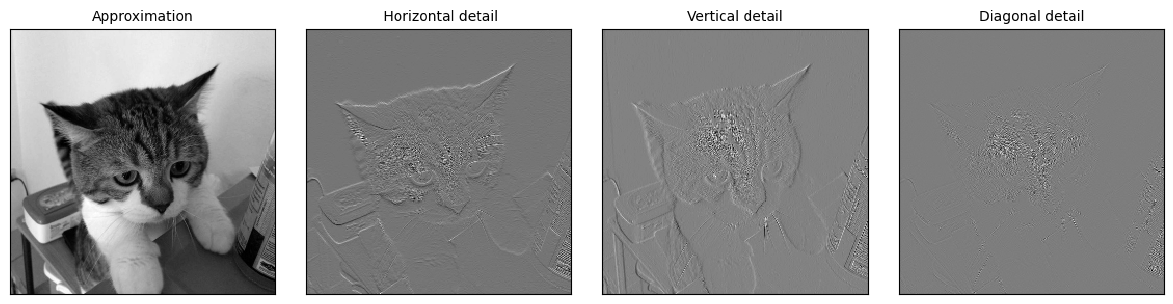

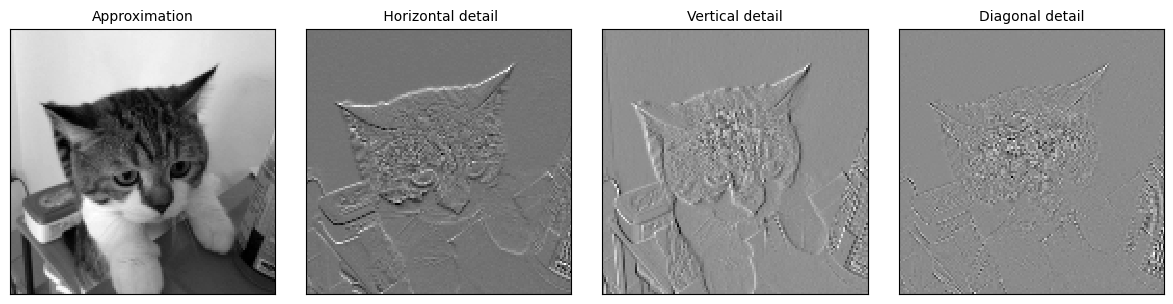

In [5]:
import pywt
import cv2
import matplotlib.pyplot as plt
original = cv2.imread("kitty.jpg",0)
titles = ['Approximation', ' Horizontal detail',
          'Vertical detail', 'Diagonal detail']
coeffs2 = pywt.dwt2(original, 'haar')
LL, (LH, HL, HH) = coeffs2
fig = plt.figure(figsize=(12, 3))
for i, a in enumerate([LL, LH, HL, HH]):
    ax = fig.add_subplot(1, 4, i + 1)
    ax.imshow(a, interpolation="nearest", cmap=plt.cm.gray)
    ax.set_title(titles[i], fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

fig.tight_layout()
plt.show()


# TO DO : Try to decompose the J-1 th layer
coeffs2 = pywt.dwt2(LL, 'haar')
LL, (LH, HL, HH) = coeffs2
fig = plt.figure(figsize=(12, 3))
for i, a in enumerate([LL, LH, HL, HH]):
    ax = fig.add_subplot(1, 4, i + 1)
    ax.imshow(a, interpolation="nearest", cmap=plt.cm.gray)
    ax.set_title(titles[i], fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

fig.tight_layout()
plt.show()



# TO DO : Try to decompose the J-2 th layer


-135.25000000000003 166.00000000000006


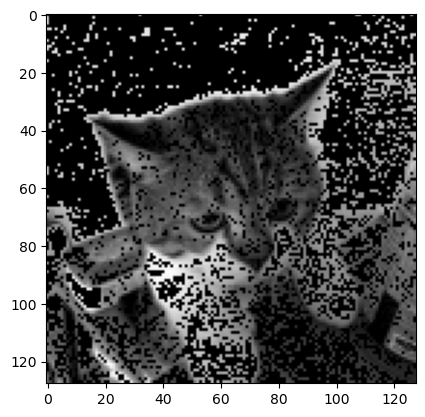

In [6]:
print(LH.min(),LH.max())
LL[abs(LH) < 3] = 0
plt.imshow(LL,cmap='gray')
plt.show()

## Exercise #2 Can you segment the Cat?
* Apply wavelet transform into ”kitty.jpg” image
* Again, investigate the min/max values in the approximation, horizontal, vertical and diagonal details.
* Can you select a threshold value to separate the high details from the low and segment the cat out?


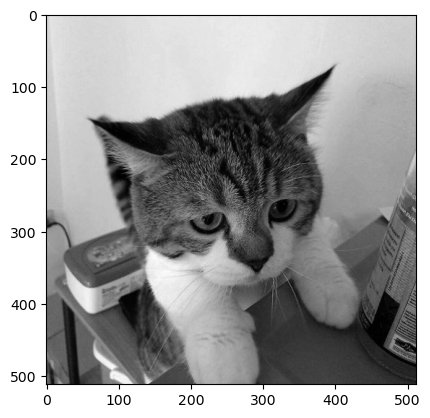

In [7]:
original = cv2.imread("kitty.jpg",0)
LL, (LH, HL, HH) = pywt.dwt2(original, 'haar')

# # TO DO : use wavelet details to segment the cat
plt.imshow(original,cmap='gray')
plt.show()
